
# Random Forest Regressor Pipeline (Notebook Version)

This notebook replicates the core steps from `torch_prep_kfold.py` **without** K-folds, focused on a clear, linear pipeline:

1. Load two CSVs and merge on a key.
2. Train/test split **by sequence** (regression).
3. Keep **last 90%** of rows per sequence (based on temporal order: sequence → run → frame/time if available).
4. Average numeric features in groups of `navg=280` **per sequence**.
5. Standardize features using **train mean/std** (label unaffected); apply the same transform to test.
6. Train a **RandomForestRegressor** and evaluate (MSE, MAE, R²).
7. Save the fitted model & scaler.

> ⚙️ **You must configure the paths and column names in the first cell below.**


In [80]:
import os, sys, logging
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score, f1_score
from sklearn.model_selection import GroupShuffleSplit

from joblib import dump

os.makedirs(OUTPUT_DIR, exist_ok=True)
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")

In [81]:

# --- CONFIG ---
DATA_FEATURES_CSV = "rawdat.csv"          # computed/processed features
DATA_LABELS_CSV   = "exp_data_all.csv"    # experimental labels
OUTPUT_DIR        = "outputs"             # where to save artifacts
# OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Column names (edit to match your files)
ID_COL      = "sequence"       # key column present in BOTH CSVs to merge on
LABEL_COL   = "bind_avg"     # the regression target
RUN_COL     = "run"          # optional temporal column 1 (e.g., run index)
FRAME_COLS  = []  # optional temporal column 2 (first found is used)

# Split / filtering / aggregation
TEST_SIZE        = 0.2       # fraction of sequences for test split
RANDOM_STATE     = 42
KEEP_LAST_PCT    = 100.0      # keep last X% per sequence
NAVG             = 280       # average numeric features in chunks of N rows per sequence

# Model
N_ESTIMATORS     = 300
MAX_DEPTH        = 10
N_JOBS           = -1

MAX_FEATURES     = "sqrt"
MIN_SAMPLES_SPLIT = 50        
MIN_SAMPLES_LEAF  = 20 

# Metrics to show
from pprint import pprint
print("Config loaded:")
pprint({
    "features_csv": DATA_FEATURES_CSV,
    "labels_csv": DATA_LABELS_CSV,
    "id_col": ID_COL,
    "label_col": LABEL_COL,
    "run_col": RUN_COL,
    "frame_cols": FRAME_COLS,
    "test_size": TEST_SIZE,
    "random_state": RANDOM_STATE,
    "keep_last_pct": KEEP_LAST_PCT,
    "navg": NAVG,
    "rf_params": {"n_estimators": N_ESTIMATORS, "max_depth": MAX_DEPTH, "n_jobs": N_JOBS},
})


Config loaded:
{'features_csv': 'rawdat.csv',
 'frame_cols': [],
 'id_col': 'sequence',
 'keep_last_pct': 100.0,
 'label_col': 'bind_avg',
 'labels_csv': 'exp_data_all.csv',
 'navg': 280,
 'random_state': 42,
 'rf_params': {'max_depth': 10, 'n_estimators': 300, 'n_jobs': -1},
 'run_col': 'run',
 'test_size': 0.2}


In [82]:


def load_csv(filename: str, usecols=None) -> pd.DataFrame:
    df = pd.read_csv(filename, usecols=usecols)
    logging.info(f"Loaded {filename}: shape={df.shape}")
    return df

def require_columns(df: pd.DataFrame, required):
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns {missing}. Available: {df.columns.tolist()}")

def find_first_existing(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def keep_last_n_percent(df: pd.DataFrame, seq_col: str, keep_percent: float,
                        run_col: str=None, frame_col: str=None) -> pd.DataFrame:
    """Keep the last keep_percent% rows per sequence based on temporal sort.
    Sort key: seq_col -> (run_col if present) -> (frame_col if present)."""
    if keep_percent <= 0 or keep_percent >= 100:
        return df.copy()

    sort_cols = [seq_col]
    if run_col and run_col in df.columns:
        sort_cols.append(run_col)
    if frame_col and frame_col in df.columns:
        sort_cols.append(frame_col)

    if len(sort_cols) > 1:
        df_sorted = df.sort_values(sort_cols, kind="mergesort")
    else:
        # fall back to current order if no temporal columns
        df_sorted = df.copy()

    group_sizes = df_sorted.groupby(seq_col)[seq_col].transform("size")
    cumcount = df_sorted.groupby(seq_col).cumcount()
    n_keep = (group_sizes * (keep_percent / 100.0)).astype(int)
    n_keep = n_keep.mask(n_keep < 1, 1)  # ensure at least one if >0%
    mask = cumcount >= (group_sizes - n_keep)
    return df_sorted[mask].reset_index(drop=True)

def average_in_chunks_per_sequence(df: pd.DataFrame, seq_col: str, chunk_size: int,
                                   label_col: str, non_numeric_keep=None) -> pd.DataFrame:
    """Average numeric columns over non-overlapping windows of size chunk_size per sequence.
    - Keeps label by averaging within the chunk (or you can choose median).
    - Keeps non-numeric / identifier columns by taking the first value in the chunk.
    - Drops partial trailing chunks smaller than chunk_size to keep shapes consistent."""
    if non_numeric_keep is None:
        non_numeric_keep = []

    dfs = []
    for seq, sub in df.groupby(seq_col, sort=False):
        n = len(sub)
        n_full = (n // chunk_size) * chunk_size
        if n_full == 0:
            continue
        sub = sub.iloc[:n_full].copy()

        # Add a chunk index within the sequence
        idx = np.arange(n_full) // chunk_size
        sub["_chunk"] = idx

        numeric_cols = sub.select_dtypes(include=[np.number]).columns.tolist()
        # Ensure label is included in numeric averaging if numeric
        if label_col in sub.columns and label_col not in numeric_cols:
            # label might be non-numeric -> try coerce to numeric (optional)
            try:
                sub[label_col] = pd.to_numeric(sub[label_col], errors="coerce")
            except Exception:
                pass
            numeric_cols = sub.select_dtypes(include=[np.number]).columns.tolist()

        # Group-aggregate
        agg_numeric = sub.groupby([seq_col, "_chunk"])[numeric_cols].mean()

        # For non-numeric/id columns we want to keep, take the first row of each chunk
        keep_cols = list({seq_col, label_col, *non_numeric_keep} & set(sub.columns))
        agg_first = sub.groupby([seq_col, "_chunk"])[keep_cols].first()

        out = pd.concat([agg_first, agg_numeric], axis=1)
        # If duplicates due to overlap, numeric cols will duplicate; resolve by grouping again
        out = out.groupby(level=[0,1]).first().reset_index(drop=True)
        dfs.append(out)

    if not dfs:
        return pd.DataFrame()

    result = pd.concat(dfs, axis=0, ignore_index=True)

    # If label_col is duplicated (from numeric+first), keep numeric-averaged version
    if label_col in result.columns:
        # Remove possible duplicate columns with suffixes; ensure single label column
        result = result.loc[:, ~result.columns.duplicated()]

    return result

def standardize_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    scaler = StandardScaler(with_mean=True, with_std=True)
    scaler.fit(X_train)
    X_train_s = pd.DataFrame(scaler.transform(X_train), columns=X_train.columns, index=X_train.index)
    X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=X_test.columns,  index=X_test.index)
    return scaler, X_train_s, X_test_s



## 1) Load CSVs and Merge
Both CSVs must contain the key column (`ID_COL`). The merged DataFrame must include the target (`LABEL_COL`).


In [83]:

feat_df = load_csv(DATA_FEATURES_CSV)
lab_df  = load_csv(DATA_LABELS_CSV)

require_columns(feat_df, [ID_COL])
require_columns(lab_df,  [ID_COL, LABEL_COL])

df = feat_df.merge(lab_df[[ID_COL, LABEL_COL]], on=ID_COL, how="inner")
logging.info(f"Merged shape: {df.shape}")
display(df.head())


INFO: Loaded rawdat.csv: shape=(272160, 10)
INFO: Loaded exp_data_all.csv: shape=(168, 4)
INFO: Merged shape: (68040, 11)


,sequence,run,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,bind_avg
0,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-236.997,-1869.660,1823.216,-35.292,-2.590101,-156.445725,-4.282747,-24.750849,0.166339
1,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-218.620,-1850.331,1807.831,-32.521,-2.977171,-142.709472,-7.240534,-25.235404,0.166339
2,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-232.611,-1878.075,1834.181,-34.170,-3.105868,-145.088977,-8.856276,-25.124940,0.166339
3,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-203.677,-1870.595,1823.641,-32.402,-3.414769,-150.961716,-5.338670,-23.079573,0.166339
4,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,9,-212.279,-1864.730,1820.462,-31.858,-3.571942,-146.583284,-7.171679,-22.812241,0.166339



## 2) Train/Test Split by Sequence
We split on **unique sequences** to avoid leakage (all rows of a given sequence go to either train or test).


In [84]:

# Unique sequence ids for grouping
seq_ids = df[ID_COL].values

gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(df, groups=seq_ids))

df_train = df.iloc[train_idx].copy()
df_test  = df.iloc[test_idx].copy()

logging.info(f"Train shape: {df_train.shape} | Test shape: {df_test.shape}")


INFO: Train shape: (53460, 11) | Test shape: (14580, 11)



## 3) Keep Last X% per Sequence
Temporal ordering uses `ID_COL → RUN_COL → first existing FRAME_COL` (if present). If no temporal column is found, current order is used.


In [85]:

frame_col = find_first_existing(df, FRAME_COLS)
logging.info(f"Temporal columns: run={RUN_COL if RUN_COL in df.columns else None}, frame={frame_col}")

df_train_f = keep_last_n_percent(df_train, seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
                                 run_col=RUN_COL if RUN_COL in df.columns else None,
                                 frame_col=frame_col)
df_test_f  = keep_last_n_percent(df_test,  seq_col=ID_COL, keep_percent=KEEP_LAST_PCT,
                                 run_col=RUN_COL if RUN_COL in df.columns else None,
                                 frame_col=frame_col)

logging.info(f"After keep_last {KEEP_LAST_PCT}% -> Train: {df_train_f.shape} | Test: {df_test_f.shape}")


INFO: Temporal columns: run=run, frame=None
INFO: After keep_last 100.0% -> Train: (53460, 11) | Test: (14580, 11)



## 4) Average Numeric Columns in Chunks of `navg=280` per Sequence
We average **numeric features** (and label if numeric) in non-overlapping windows. Partial trailing windows are dropped to keep shapes consistent.


In [86]:

# Choose non-numeric columns you want to preserve per chunk (optional)
NON_NUMERIC_KEEP = [ID_COL, RUN_COL] if RUN_COL in df.columns else [ID_COL]

df_train_avg = average_in_chunks_per_sequence(df_train_f, seq_col=ID_COL, chunk_size=NAVG,
                                              label_col=LABEL_COL, non_numeric_keep=NON_NUMERIC_KEEP)
df_test_avg  = average_in_chunks_per_sequence(df_test_f,  seq_col=ID_COL, chunk_size=NAVG,
                                              label_col=LABEL_COL, non_numeric_keep=NON_NUMERIC_KEEP)

# df_train_avg = df_train.groupby("sequence", as_index=False).mean(numeric_only=True)
# df_test_avg  = df_test.groupby("sequence", as_index=False).mean(numeric_only=True)


logging.info(f"Averaged -> Train: {df_train_avg.shape} | Test: {df_test_avg.shape}")
display(df_train_avg.head())


INFO: Averaged -> Train: (165, 12) | Test: (45, 12)


,run,bind_avg,sequence,VDWAALS,EEL,EGB,ESURF,HB Energy,Hydrophobic Energy,Pi-Pi Energy,Delta_Entropy,_chunk
0,9,0.166339,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,-199.399254,-1907.759246,1857.998729,-31.121718,-3.283449,-135.427770,-3.331060,-21.603125,0.0
1,1,0.166339,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,-204.229925,-1917.534732,1866.965379,-31.845250,-3.398454,-139.080064,-2.245146,-21.916852,1.0
2,7,0.166339,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,-199.722011,-1904.139825,1854.365768,-31.023057,-3.323599,-136.358836,-3.645865,-21.442966,2.0
3,12,0.166339,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,-198.678636,-1910.886943,1860.437925,-31.083286,-3.356259,-135.997524,-2.804169,-21.945606,3.0
4,20,0.166339,CAGGGCTGGGTCCACCTCATGGCCTTTGTTCTGGAA,-200.142032,-1909.133939,1858.307096,-31.520368,-3.541798,-138.241284,-2.846498,-22.020984,4.0



## 5) Standardize Features (Train Mean/Std) — Label Unchanged
We compute mean/std on **train** features only, then transform both train and test for unbiased evaluation.


In [87]:

# Build X, y
def split_X_y(df_xy: pd.DataFrame, label_col: str):
    require_columns(df_xy, [label_col])
    y = df_xy[label_col].copy()
    # Drop non-feature columns: label + sequence + any obvious meta columns
    drop_cols = {label_col, ID_COL, "_chunk"}
    if RUN_COL in df_xy.columns:
        drop_cols.add(RUN_COL)
    # Remove non-numeric columns from features automatically
    X = df_xy.drop(columns=list(drop_cols), errors="ignore")
    X = X.select_dtypes(include=[np.number])
    return X, y

X_train, y_train = split_X_y(df_train_avg, LABEL_COL)
X_test,  y_test  = split_X_y(df_test_avg,  LABEL_COL)

logging.info(f"Feature shapes -> X_train: {X_train.shape}, X_test: {X_test.shape}")

scaler, X_train_s, X_test_s = standardize_train_test(X_train, X_test)


INFO: Feature shapes -> X_train: (165, 8), X_test: (45, 8)



## 6) Train RandomForestRegressor and Evaluate
Metrics: **MSE**, **MAE**, **R²**.


In [88]:

rf = RandomForestRegressor(
    n_estimators=N_ESTIMATORS,
    max_depth=MAX_DEPTH,
    max_features=MAX_FEATURES,         # <- added
    min_samples_split=MIN_SAMPLES_SPLIT,  # <- added
    min_samples_leaf=MIN_SAMPLES_LEAF,    # <- added
    n_jobs=N_JOBS,
    random_state=RANDOM_STATE,
)


rf.fit(X_train_s, y_train)
pred_train = rf.predict(X_train_s)
pred_test  = rf.predict(X_test_s)

metrics = {
    "train": {
        "MSE": mean_squared_error(y_train, pred_train),
        "MAE": mean_absolute_error(y_train, pred_train),
        "R2":  r2_score(y_train, pred_train),
    },
    "test": {
        "MSE": mean_squared_error(y_test, pred_test),
        "MAE": mean_absolute_error(y_test, pred_test),
        "R2":  r2_score(y_test, pred_test),
    }
}
print("Metrics:")
pprint(metrics)


Metrics:
{'test': {'MAE': 0.48951454487989493,
          'MSE': 0.3174461303955625,
          'R2': 0.38345621246052874},
 'train': {'MAE': 0.565567247836214,
           'MSE': 0.4889980899398328,
           'R2': 0.33574845413186716}}



## 7) Save Artifacts (Model & Scaler)
Saves `.joblib` files for reuse.


In [89]:

model_path  = os.path.join(OUTPUT_DIR, "rf_regressor.joblib")
scaler_path = os.path.join(OUTPUT_DIR, "scaler.joblib")

dump(rf, model_path)
dump(scaler, scaler_path)

print("Saved:")
print(model_path)
print(scaler_path)


Saved:
outputs/rf_regressor.joblib
outputs/scaler.joblib



## Notes & Tips

- **Temporal order**: We sort by `seq_id → run → frame/time` if available. Ensure your CSVs have these columns; otherwise, define an appropriate temporal key.
- **Per-sequence vs per-run**: This notebook keeps last 90% **per sequence**. If you want last 90% **per run**, group by `[seq_id, run]` when computing sizes/cumcount.
- **Averaging (`navg`)**: Non-overlapping windows; trailing partial chunks are dropped.
- **Standardization**: Fit on **train** only; transform both train and test.
- **Label column**: Not standardized.
- **Hyperparameters**: Adjust `N_ESTIMATORS`, `MAX_DEPTH` as needed. For reproducibility, keep `RANDOM_STATE` fixed.
- **Leakage guard**: The split is done **by sequence** so test sequences were never seen during training.


In [90]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
try:
    from scipy.stats import pearsonr
    _has_scipy = True
except Exception:
    _has_scipy = False

In [91]:
# Sign convention: usually ΔG_bind < 0 => "Binding"
THRESH = 0.0
BIND_IS_NEGATIVE = True  # if False, binding means value >= THRESH

def pcc(a, b):
    if _has_scipy:
        r, _ = pearsonr(a, b)
        return r
    # fallback
    return np.corrcoef(a, b)[0,1]

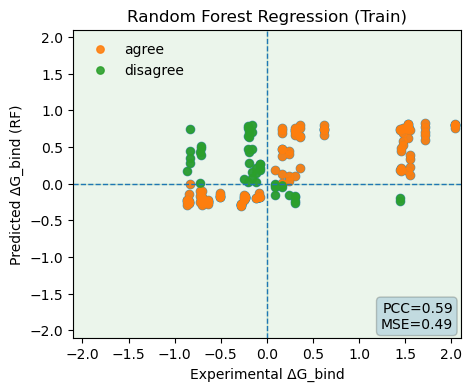

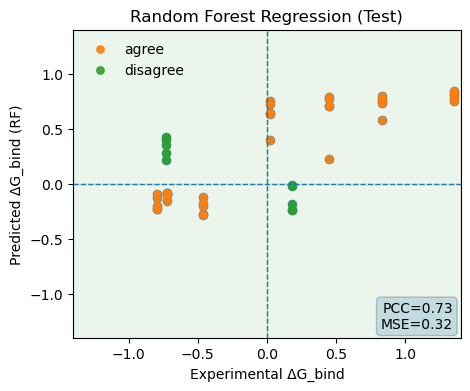

({'PCC': 0.592964130834471, 'MSE': 0.4889980899398328},
 {'PCC': 0.734013706729634, 'MSE': 0.3174461303955625})

In [92]:
def scatter_with_quadrants(y_true, y_pred, title):
    # Axes limits symmetrical around 0 (like the paper’s look)
    x = np.asarray(y_true)
    y = np.asarray(y_pred)
    lim = max(np.max(np.abs(x)), np.max(np.abs(y)))
    lim = float(np.ceil(lim * 10) / 10.0)

    # Compute metrics
    _pcc = pcc(x, y)
    _mse = np.mean((x - y)**2)

    fig, ax = plt.subplots(figsize=(5, 4))
    ax.scatter(x, y, alpha=0.7)

    # zero lines
    ax.axvline(0, linestyle="--", linewidth=1)
    ax.axhline(0, linestyle="--", linewidth=1)

    # quadrant shading: agree on sign (both <0 OR both >=0) -> green; disagree -> red
    agree = np.sign(x - THRESH) == np.sign(y - THRESH)
    disagree = ~agree

    # light background shading by quadrants
    ax.fill_between([-lim, 0], 0,  lim, alpha=0.08, step="pre", color="green")  # QI (x<0,y>0) to be red later
    ax.fill_between([-lim, 0], -lim, 0, alpha=0.08, step="pre", color="green")
    ax.fill_between([0, lim],  0,  lim, alpha=0.08, step="pre", color="green")
    ax.fill_between([0, lim], -lim, 0, alpha=0.08, step="pre", color="green")

    # Re-plot points colored by agreement for clarity
    ax.scatter(x[agree],    y[agree],    alpha=0.9, label="agree", s=28)
    ax.scatter(x[disagree], y[disagree], alpha=0.9, label="disagree", s=28)

    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)
    ax.set_xlabel("Experimental ΔG_bind")
    ax.set_ylabel("Predicted ΔG_bind (RF)")
    ax.set_title(title)

    # Add PCC & MSE box (like the figure)
    ax.text(0.98, 0.02, f"PCC={_pcc:.2f}\nMSE={_mse:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(boxstyle="round", alpha=0.2))

    ax.legend(loc="upper left", frameon=False)
    plt.show()
    return {"PCC": _pcc, "MSE": _mse}

# Use the predictions you already computed:
# y_train, pred_train, y_test, pred_test

metrics_A_train = scatter_with_quadrants(y_train, pred_train, "Random Forest Regression (Train)")
metrics_A_test  = scatter_with_quadrants(y_test,  pred_test,  "Random Forest Regression (Test)")
metrics_A_train, metrics_A_test


In [93]:
feature_importance = pd.DataFrame({
    "Feature": X_train_s.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importances:")
display(feature_importance)

# Save to CSV for reference
feature_importance.to_csv(f"{OUTPUT_DIR}/rf_feature_importance.csv", index=False)

Random Forest Feature Importances:


,Feature,Importance
5,Hydrophobic Energy,0.261166
0,VDWAALS,0.235654
3,ESURF,0.200961
7,Delta_Entropy,0.148107
6,Pi-Pi Energy,0.057084
4,HB Energy,0.045486
1,EEL,0.033904
2,EGB,0.017637


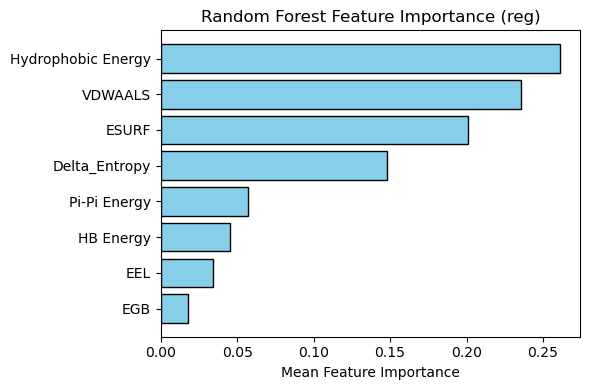

In [94]:
def plot_feature_importance(df_imp, title="Random Forest Feature Importance (reg)"):
    df = df_imp.copy()
    df = df.sort_values("Importance", ascending=True)  # smaller → top, like paper
    plt.figure(figsize=(6,4))
    plt.barh(df["Feature"], df["Importance"], color="skyblue", edgecolor="black")
    plt.xlabel("Mean Feature Importance")
    plt.title(title)
    plt.tight_layout()
    plt.show()

plot_feature_importance(feature_importance)

# K-fold Cross Validation

After the data prep (after keep-last-90% and navg=280), we can use the following code to get results pertaining to the best model as shown in the original paper after averaging with K-fold CV. This replaces the above shown single train/test with GroupKFold CV and produces:
- mean ± std of (MSE, MAE, R², PCC, Acc, F1) across folds
- one sequence-level point per sequence (averaged across folds) to plot Figure A
- train/test confusion matrices like Figure B (using test folds)

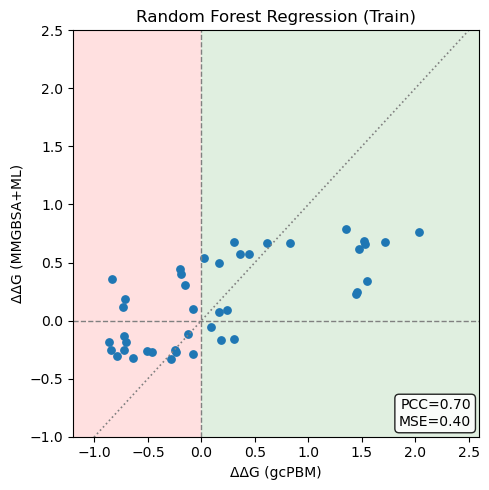

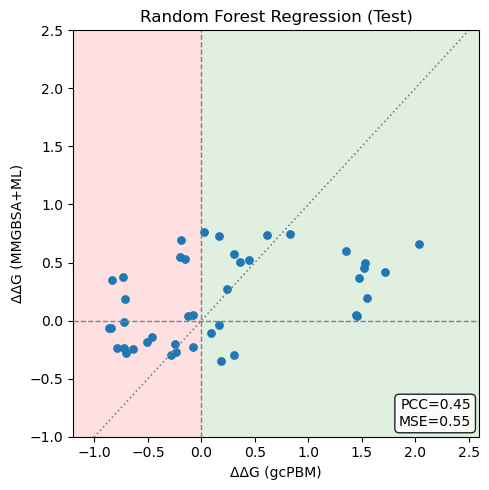

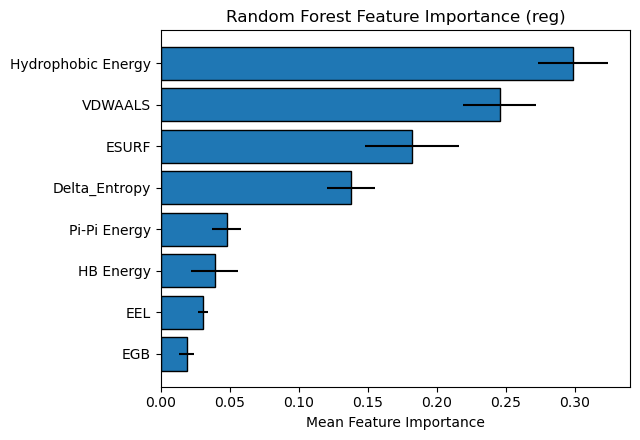

In [96]:
# ==== CV with per-sequence TRAIN and TEST points + feature importances ====
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import pearsonr
    _has_scipy = True
except:
    _has_scipy = False

def pcc(a,b):
    if _has_scipy:
        r,_ = pearsonr(a,b); return r
    return np.corrcoef(a,b)[0,1]

def build_Xy(df_xy, label_col, id_col, run_col=None):
    drops = {label_col, id_col, "_chunk"}
    if run_col in df_xy.columns: drops.add(run_col)
    X = df_xy.drop(columns=list(drops), errors="ignore").select_dtypes(include=[np.number])
    y = df_xy[label_col].astype(float).copy()
    ids = df_xy[id_col].values
    return X, y, ids

def collapse_seq_means(df, id_col, y_col, yhat_col):
    g = df.groupby(id_col, sort=False)
    return pd.DataFrame({
        id_col: g.size().index,
        "y_true_seq": g[y_col].mean().values,
        "y_pred_seq": g[yhat_col].mean().values,
    })

def scatter_paper_style(x, y, title, xlim=(-1.2, 2.6), ylim=(-1.0, 2.5)):
    x = np.asarray(x); y = np.asarray(y)
    R = pcc(x, y); M = mean_squared_error(x, y)

    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    # green (agree) / red (disagree) quadrants
    ax.axvspan(xlim[0], 0, ylim[0], 0, facecolor="green", alpha=0.12)
    ax.axvspan(0, xlim[1], 0, ylim[1], facecolor="green", alpha=0.12)
    ax.axvspan(xlim[0], 0, 0, ylim[1], facecolor="red",   alpha=0.12)
    ax.axvspan(0, xlim[1], ylim[0], 0, facecolor="red",   alpha=0.12)
    # zero lines + y=x
    ax.axvline(0, ls="--", lw=1, color="gray")
    ax.axhline(0, ls="--", lw=1, color="gray")
    xs = np.linspace(*xlim, 200)
    ax.plot(xs, xs, ls=":", lw=1.2, color="gray")

    ax.scatter(x, y, s=28)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect((xlim[1]-xlim[0])/(ylim[1]-ylim[0]))
    ax.set_xlabel("ΔΔG (gcPBM)")           # experimental
    ax.set_ylabel("ΔΔG (MMGBSA+ML)")       # predicted
    ax.set_title(title)
    ax.text(0.98, 0.02, f"PCC={R:.2f}\nMSE={M:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    plt.tight_layout(); plt.show()
    return {"PCC": R, "MSE": M}

# Use your already-prepped table (after keep/average steps),
# or switch to full-sequence averaging if you decided to do that.
df_all = pd.concat([df_train_avg, df_test_avg], axis=0, ignore_index=True)

X_all, y_all, ids_all = build_Xy(df_all, LABEL_COL, ID_COL, run_col=RUN_COL)

K = 5
gkf = GroupKFold(n_splits=K)

# Collect OOF TEST rows and in-fold TRAIN rows
test_rows, train_rows = [], []
imp_matrix = []  # feature importances per fold

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, groups=ids_all), 1):
    Xtr, Xte = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    ytr, yte = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    id_tr, id_te = ids_all[tr_idx], ids_all[te_idx]

    scaler = StandardScaler()
    Xtr_s = pd.DataFrame(scaler.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_s = pd.DataFrame(scaler.transform(Xte),     columns=Xte.columns, index=Xte.index)

    rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        max_features=MAX_FEATURES,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    rf.fit(Xtr_s, ytr)

    # Save feature importances
    imp_matrix.append(rf.feature_importances_)

    # In-fold TRAIN predictions (for the "Train" panel)
    yhat_tr = rf.predict(Xtr_s)
    train_rows.append(pd.DataFrame({ID_COL: id_tr, "y_true": ytr.values, "y_pred": yhat_tr}))

    # OOF TEST predictions (for the "Test" panel)
    yhat_te = rf.predict(Xte_s)
    test_rows.append(pd.DataFrame({ID_COL: id_te, "y_true": yte.values, "y_pred": yhat_te}))

train_oof = pd.concat(train_rows, axis=0, ignore_index=True)
test_oof  = pd.concat(test_rows,  axis=0, ignore_index=True)

# Collapse to one point per sequence (mean within sequence)
train_seq = collapse_seq_means(train_oof, ID_COL, "y_true", "y_pred")
test_seq  = collapse_seq_means(test_oof,  ID_COL, "y_true", "y_pred")

# --- Scatter plots like the paper ---
_ = scatter_paper_style(train_seq["y_true_seq"], train_seq["y_pred_seq"],
                        "Random Forest Regression (Train)")
_ = scatter_paper_style(test_seq["y_true_seq"],  test_seq["y_pred_seq"],
                        "Random Forest Regression (Test)")

# --- Feature importance (mean ± sd across folds) ---
imp_mat = np.vstack(imp_matrix)                     # shape: (K, n_features)
imp_mean = imp_mat.mean(axis=0)
imp_std  = imp_mat.std(axis=0, ddof=1)

fi = pd.DataFrame({"Feature": X_all.columns, "Mean": imp_mean, "Std": imp_std})\
        .sort_values("Mean", ascending=True)

plt.figure(figsize=(6.5, 4.5))
plt.barh(fi["Feature"], fi["Mean"], xerr=fi["Std"], edgecolor="black")
plt.xlabel("Mean Feature Importance")
plt.title("Random Forest Feature Importance (reg)")
plt.tight_layout(); plt.show()

# also keep a tidy table if you want
fi.to_csv(f"{OUTPUT_DIR}/rf_feature_importance_cv.csv", index=False)


## Removed EGB
Since EEG and EGB are correlated inversely, we tried to get rid of one feature and then see the feature importances order.

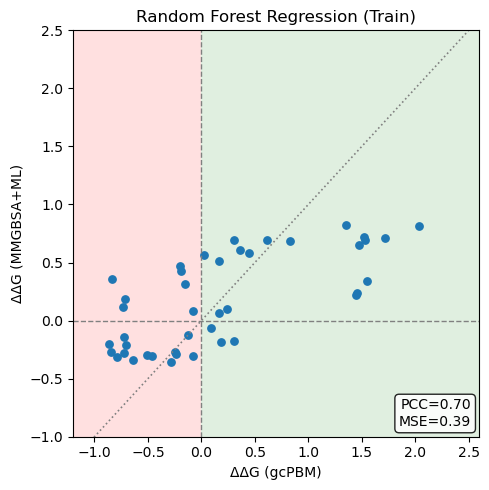

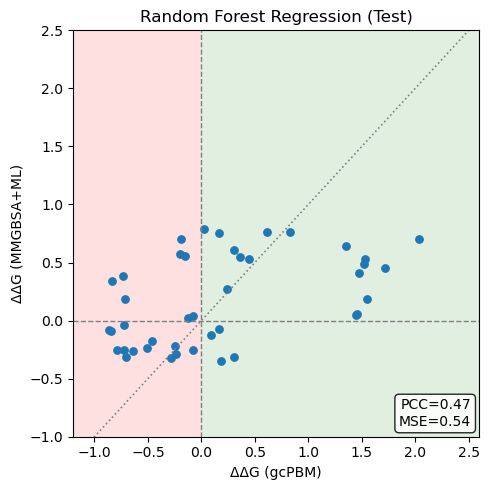

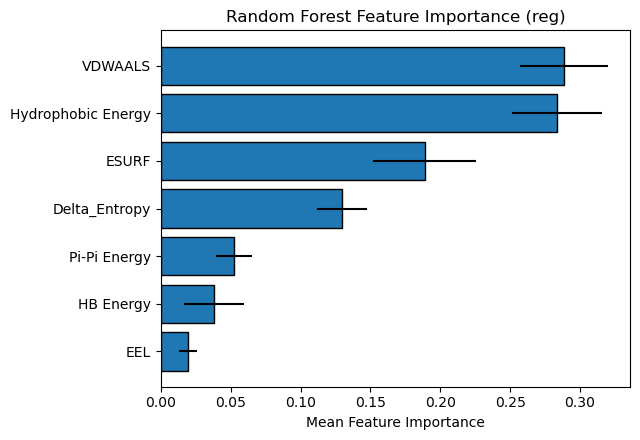

In [97]:
# ==== CV with per-sequence TRAIN and TEST points + feature importances ====
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import pearsonr
    _has_scipy = True
except:
    _has_scipy = False

def pcc(a,b):
    if _has_scipy:
        r,_ = pearsonr(a,b); return r
    return np.corrcoef(a,b)[0,1]

def build_Xy(df_xy, label_col, id_col, run_col=None):
    drops = {label_col, id_col, "_chunk", "EGB"}
    if run_col in df_xy.columns: drops.add(run_col)
    X = df_xy.drop(columns=list(drops), errors="ignore").select_dtypes(include=[np.number])
    y = df_xy[label_col].astype(float).copy()
    ids = df_xy[id_col].values
    return X, y, ids

def collapse_seq_means(df, id_col, y_col, yhat_col):
    g = df.groupby(id_col, sort=False)
    return pd.DataFrame({
        id_col: g.size().index,
        "y_true_seq": g[y_col].mean().values,
        "y_pred_seq": g[yhat_col].mean().values,
    })

def scatter_paper_style(x, y, title, xlim=(-1.2, 2.6), ylim=(-1.0, 2.5)):
    x = np.asarray(x); y = np.asarray(y)
    R = pcc(x, y); M = mean_squared_error(x, y)

    fig, ax = plt.subplots(figsize=(6.5, 5.0))
    # green (agree) / red (disagree) quadrants
    ax.axvspan(xlim[0], 0, ylim[0], 0, facecolor="green", alpha=0.12)
    ax.axvspan(0, xlim[1], 0, ylim[1], facecolor="green", alpha=0.12)
    ax.axvspan(xlim[0], 0, 0, ylim[1], facecolor="red",   alpha=0.12)
    ax.axvspan(0, xlim[1], ylim[0], 0, facecolor="red",   alpha=0.12)
    # zero lines + y=x
    ax.axvline(0, ls="--", lw=1, color="gray")
    ax.axhline(0, ls="--", lw=1, color="gray")
    xs = np.linspace(*xlim, 200)
    ax.plot(xs, xs, ls=":", lw=1.2, color="gray")

    ax.scatter(x, y, s=28)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_aspect((xlim[1]-xlim[0])/(ylim[1]-ylim[0]))
    ax.set_xlabel("ΔΔG (gcPBM)")           # experimental
    ax.set_ylabel("ΔΔG (MMGBSA+ML)")       # predicted
    ax.set_title(title)
    ax.text(0.98, 0.02, f"PCC={R:.2f}\nMSE={M:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.85))
    plt.tight_layout(); plt.show()
    return {"PCC": R, "MSE": M}

# Use your already-prepped table (after keep/average steps),
# or switch to full-sequence averaging if you decided to do that.
df_all = pd.concat([df_train_avg, df_test_avg], axis=0, ignore_index=True)

X_all, y_all, ids_all = build_Xy(df_all, LABEL_COL, ID_COL, run_col=RUN_COL)

K = 5
gkf = GroupKFold(n_splits=K)

# Collect OOF TEST rows and in-fold TRAIN rows
test_rows, train_rows = [], []
imp_matrix = []  # feature importances per fold

for fold, (tr_idx, te_idx) in enumerate(gkf.split(X_all, groups=ids_all), 1):
    Xtr, Xte = X_all.iloc[tr_idx], X_all.iloc[te_idx]
    ytr, yte = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    id_tr, id_te = ids_all[tr_idx], ids_all[te_idx]

    scaler = StandardScaler()
    Xtr_s = pd.DataFrame(scaler.fit_transform(Xtr), columns=Xtr.columns, index=Xtr.index)
    Xte_s = pd.DataFrame(scaler.transform(Xte),     columns=Xte.columns, index=Xte.index)

    rf = RandomForestRegressor(
        n_estimators=N_ESTIMATORS,
        max_depth=MAX_DEPTH,
        max_features=MAX_FEATURES,
        min_samples_split=MIN_SAMPLES_SPLIT,
        min_samples_leaf=MIN_SAMPLES_LEAF,
        n_jobs=N_JOBS,
        random_state=RANDOM_STATE,
    )
    rf.fit(Xtr_s, ytr)

    # Save feature importances
    imp_matrix.append(rf.feature_importances_)

    # In-fold TRAIN predictions (for the "Train" panel)
    yhat_tr = rf.predict(Xtr_s)
    train_rows.append(pd.DataFrame({ID_COL: id_tr, "y_true": ytr.values, "y_pred": yhat_tr}))

    # OOF TEST predictions (for the "Test" panel)
    yhat_te = rf.predict(Xte_s)
    test_rows.append(pd.DataFrame({ID_COL: id_te, "y_true": yte.values, "y_pred": yhat_te}))

train_oof = pd.concat(train_rows, axis=0, ignore_index=True)
test_oof  = pd.concat(test_rows,  axis=0, ignore_index=True)

# Collapse to one point per sequence (mean within sequence)
train_seq = collapse_seq_means(train_oof, ID_COL, "y_true", "y_pred")
test_seq  = collapse_seq_means(test_oof,  ID_COL, "y_true", "y_pred")

# --- Scatter plots like the paper ---
_ = scatter_paper_style(train_seq["y_true_seq"], train_seq["y_pred_seq"],
                        "Random Forest Regression (Train)")
_ = scatter_paper_style(test_seq["y_true_seq"],  test_seq["y_pred_seq"],
                        "Random Forest Regression (Test)")

# --- Feature importance (mean ± sd across folds) ---
imp_mat = np.vstack(imp_matrix)                     # shape: (K, n_features)
imp_mean = imp_mat.mean(axis=0)
imp_std  = imp_mat.std(axis=0, ddof=1)

fi = pd.DataFrame({"Feature": X_all.columns, "Mean": imp_mean, "Std": imp_std})\
        .sort_values("Mean", ascending=True)

plt.figure(figsize=(6.5, 4.5))
plt.barh(fi["Feature"], fi["Mean"], xerr=fi["Std"], edgecolor="black")
plt.xlabel("Mean Feature Importance")
plt.title("Random Forest Feature Importance (reg)")
plt.tight_layout(); plt.show()

# also keep a tidy table if you want
fi.to_csv(f"{OUTPUT_DIR}/rf_feature_importance_cv.csv", index=False)
